# Structural network mapping

In this tutorial, you will explore the structural network mapping functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch a structural connectome
- Obtain voxel-level disconnectivity maps
- Compute a disconnectivity matrix
- Compute ROI-wise disconnection values

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/structural-network-mapping.ipynb)


## Colab

Run this section only when using Google Colab.

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

In [1]:
# --- Conda setup for Google Colab ---
# Lacuna's structural network mapping capabilities rely on MRtrix3.
# However, Colab does not include conda by default, which is required for MRtrix3 installation.
# We use condacolab to replace Colab's Python with a Mambaforge-based environment.
#
# IMPORTANT: Running this cell will RESTART the kernel automatically.
# After the restart, SKIP this cell and continue from the next cell onward.
# (Do NOT re-run this cell after the restart.)

import os

if os.environ.get("CONDA_PREFIX") is None:

    !pip install -q condacolab==0.1.9
    import condacolab
    condacolab.install()  # This restarts the kernel

In [2]:
# Run this after the kernel restart. 
import sys

if 'google.colab' in sys.modules:

    import condacolab
    import subprocess

    condacolab.check()

    conda_paths = subprocess.check_output(
        "python -c 'import sys; print(\"\\n\".join(sys.path))'", 
        shell=True, text=True
    ).split('\n')

    for path in conda_paths:
        if path and path not in sys.path:
            sys.path.append(path)
    
    print("Colab environment detected: condacolab initialized.")

## Setup

In [3]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -c conda-forge -c MRtrix3 mrtrix3 libstdcxx-ng -y

# Install yabplot and pyvista for visualization
!pip install yabplot pyvista==0.47.1

  Cloning https://github.com/m-petersen/lacuna to /tmp/pip-req-build-farknirt
  Running command git clone --filter=blob:none --quiet https://github.com/m-petersen/lacuna /tmp/pip-req-build-farknirt
  Resolved https://github.com/m-petersen/lacuna to commit 030c4afa567af54e1ffb8eaf41b1142804c7219a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lacuna: filename=lacuna-0.0.1.dev368-py3-none-any.whl size=3976300 sha256=dd243a0a2250af63d8ac45b08e271ff2b10930eba153dde9ef658b3a6b8a54a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-gdr5j5b4/wheels/f2/47/73/b700514669e601f0dde178de2d7016138fa840bd514ac68002
Successfully built lacuna
  Attempting uninstall: lacuna
    Found existing installation: lacuna 0.0.1.dev355
    Uninstalling lacuna-0.0.1.dev355:
      Successfully uninstalled lacuna-0.0.1.dev355
Solving environment: | 
  - mrtrix3/linux-64::mrtrix3-3.0.8-h07fc403_0
  - MRtrix3/l

Get the tutorial data.

In [4]:
!lacuna tutorial /tmp/tutorial_bids


Setting up tutorial data at: /tmp/tutorial_bids
Error: Directory already exists: /tmp/tutorial_bids
       Use --force to overwrite, or choose a different location.


Check whether mrtrix3 is properly installed as it is required for the analysis.

In [5]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch structural connectome

Structural lesion network mapping requires a structural connectome in the form of a normative tractogram, i.e., white matter fiber bundle reconstruction derived from diffusion-weighted MRI.

When selecting a connectome, the main difference lies in the trade-off between sensitivity and anatomical specificity:

If possible, we recommend using [dTOR985](https://springernature.figshare.com/articles/dataset/dTOR-985_structural_connectome_full_tractogram_trk_file/25209947) as its high coverage improves sensitivity. It is generated via an untargeted, whole-brain tracking approach. With ~12 million streamlines, this connectome is computationally demanding. The fetching process involves a conversion to .tck format which needs 32gb RAM. To download it you need a Figshare personal token. You can obtain this token by logging into [Figshare](https://figshare.com), navigating to Account, then Integrations, and finally selecting Personal Tokens.

In this tutorial, we use the more lightweight [HCP1065](https://brain.labsolver.org/hcp_trk_atlas.html) tractogram which is a combination of individual curated tract bundles. It uses trajectory-based recognition against an expert-vetted atlas and topology-informed pruning to remove false connections. This makes it suitable for analyses where minimizing spurious (false-positive) streamlines is a priority. However, its lower coverage lowers sensitivity.

In [6]:
!lacuna fetch hcp1065 \
    --output-dir /tmp/hcp1065_data

Fetching HCP1065 structural tractogram...
  Output: /tmp/hcp1065_data
  Keep original: True


✓ HCP1065 fetch complete!
  Files: 1
  Duration: 0.0s
  Output: /tmp/hcp1065_data


## Analysis
By filtering the normative tractogram based on the mask image, structural lesion network mapping identifies white matter fiber bundles connected to a specific lesion. By that, we can infer which pathways have been disconnected or disrupted.

What the structural network mapping implementation internally does: 
1. Ensure spatial alignment
2. Compute the voxel-level tract density image (TDI) of full tractogram (amount of streamlines per voxel)
3. Filter the normative tractogram by the lesion mask
4. Compute the TDI of the lesion filtered tractogram and divide the lesion TDI by the original TDI to obtain a disconnection map (% of streamlines connected to the lesion).



Now run the analysis.

In [7]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run1/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym

The standard run as shown above produces voxel-level disconnectivity maps.

In [8]:
!ls /tmp/outputs_snm_run1/sub-01/ses-01/anat/

sub-01_ses-01_desc-provenance.json
sub-01_ses-01_label-acuteinfarct_summarystatistics_stats.json
sub-01_ses-01_space-MNI152NLin2009cAsym_label-acuteinfarct_mask.nii.gz
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.json
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz


Visualize the output.

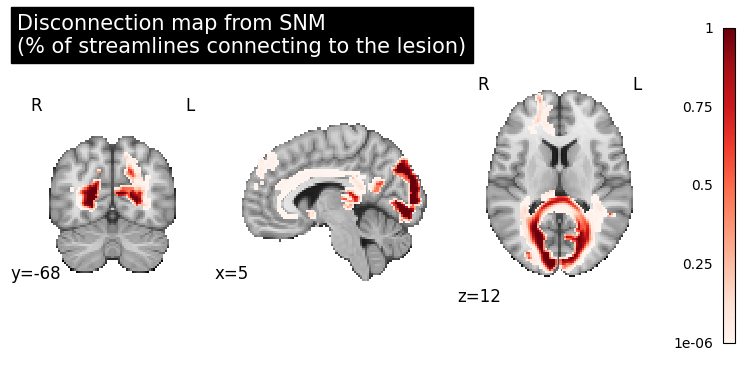

In [9]:
import nibabel as nib
from nilearn import plotting

disconnection_path = '/tmp/outputs_snm_run1/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz'
disconnection_img = nib.load(disconnection_path)

disconnection_map = plotting.plot_stat_map(disconnection_img, 
                       radiological=True, 
                       title="Disconnection map from SNM \n(% of streamlines connecting to the lesion)", 
                       draw_cross=False, 
                       colorbar=True,
                       dim=-0.2,
                       cmap='Reds')

## Obtain parcel-level disconnectivity scores and disconnectivity matrix

Beyond voxel-level maps, Lacuna covers two further formats of disconnectivity information: region of interest-level disconnectivity scores and a disconnectivity matrix.

These require the `--compute-roi-disconnection` flag as well as definition of a parcellation atlas via `--parcel-atlas`.

Run the analysis again with these flags.

In [10]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run2/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --compute-disconnectivity-matrix \
    --compute-roi-disconnection \
    --parcel-atlas Schaefer2018_100Parcels7Networks


Matrix outputs comprise four complementary connectivity representations:
1. Disconnectivity matrix – percentage of streamlines disconnected by the lesion
2. Mask connectivity matrix – number of streamlines traversing the lesion mask
3. Intact connectivity matrix – number of remaining streamlines after excluding those passing through the lesion (i.e., total minus mask connectivity)
4. Full connectome matrix – total number of streamlines irrespective of lesion involvement

In [11]:
!ls /tmp/outputs_snm_run2/sub-01/ses-01/anat/*matrix*

/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-fullconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-fullconnectivitymatrix_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-intactconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-i

Visualize the disconnectivity of the visual network. Because HCP1065 is mainly consisting of long fiber bundles the sparsity of the matrix is expected.

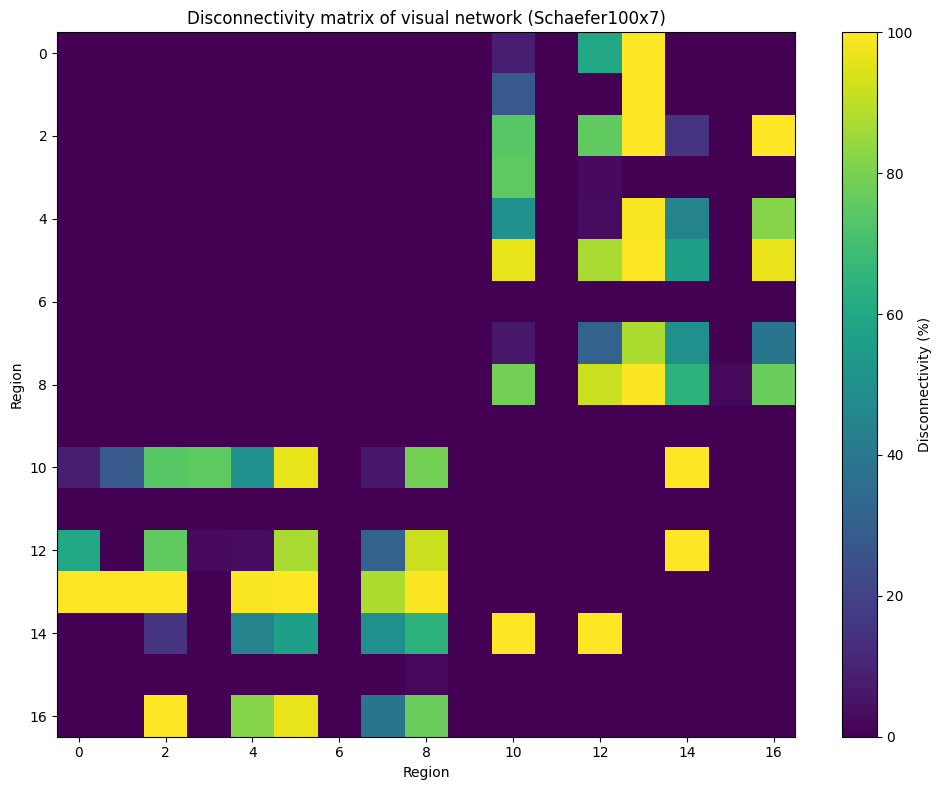

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.tsv"
mat = pd.read_csv(file_path, sep="\t", header=0, index_col=0)

visual_network_regions = [parc for parc in mat.index if "Vis" in parc]
mat = mat.loc[visual_network_regions, visual_network_regions]
mat = mat.values

plt.figure(figsize=(10, 8))
im = plt.imshow(mat, aspect='auto')
plt.colorbar(im, label="Disconnectivity (%)")

plt.title("Disconnectivity matrix of visual network (Schaefer100x7)")
plt.xlabel("Region")
plt.ylabel("Region")

im.set_clim(0, 100)

plt.tight_layout()
plt.show()

Visualize the parcel-level disconnection (%) on the cortical surface with [yabplot](https://teanijarv.github.io/yabplot/)

/tmp/ipykernel_280318/245768886.py:6: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pyvista.start_xvfb()


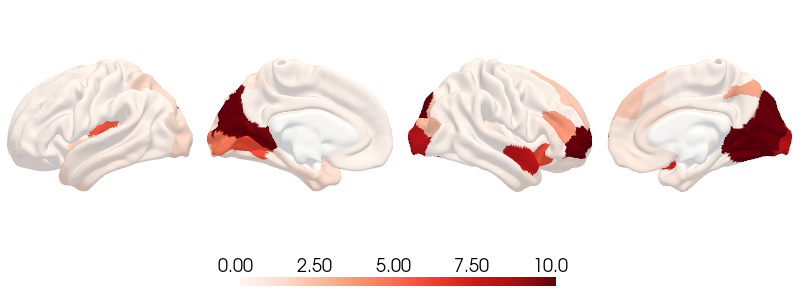

In [13]:
import pyvista
import yabplot as yab

pyvista.set_jupyter_backend('static')
pyvista.global_theme.notebook = True
pyvista.start_xvfb()

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv"

df = pd.read_csv(file_path, sep="\t", index_col=0)
values = df.values.flatten()

yab.plot_cortical(
    data=values,
    atlas='schaefer_100',
    views=['left_lateral', 'left_medial', 'right_lateral', 'right_medial'],
    figsize=(800, 300),
    vminmax=(0,10),
    cmap="Reds",
    display_type="static",
)

## Run structural network mapping on multiple subjects
Lacuna supports processing multiple subjects within a single run. If the --participant-label flag is omitted, the analysis is automatically executed for all subjects detected in the BIDS dataset. With the `--verbose` we can see which masks are detected.

Execution strategies are optimized internally for each analysis type. For structural network mapping, subjects are processed sequentially. Parallelizing across subjects is intentionally avoided, as concurrent processes would repeatedly access the same tractogram file, leading to race conditions and degraded performance.

Instead, parallelism is implemented at the single-subject level via multithreading, controlled by the `--nprocs` parameter.



In [25]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run3/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --mask-space MNI152NLin6Asym \
    --compute-roi-disconnection \
    --parcel-atlas Schaefer2018_100Parcels7Networks \
    --nprocs 12 \
    --verbose


2026-03-19 17:21:36 - lacuna.cli.main - INFO - Lacuna CLI starting
2026-03-19 17:21:36 - lacuna.cli.main - INFO - Input: /tmp/tutorial_bids
2026-03-19 17:21:36 - lacuna.cli.main - INFO - Output directory: /tmp/outputs_snm_run3
2026-03-19 17:21:36 - lacuna.cli.main - INFO - Analysis: snm
2026-03-19 17:21:36 - lacuna.cli.main - INFO - Registering structural connectome: hcp1065.tck
2026-03-19 17:21:36 - lacuna.cli.main - INFO - Running analysis: StructuralNetworkMapping
2026-03-19 17:21:36 - lacuna.cli.main - INFO - 
2026-03-19 17:21:36 - lacuna.cli.main - INFO - ============================================================
2026-03-19 17:21:36 - lacuna.cli.main - INFO - DISCOVERY SUMMARY
2026-03-19 17:21:36 - lacuna.cli.main - INFO - ============================================================
2026-03-19 17:21:36 - lacuna.cli.main - INFO -   Total mask images: 3
2026-03-19 17:21:36 - lacuna.cli.main - INFO -   Unique subjects:   3
2026-03-19 17:21:36 - lacuna.cli.main - INFO -   Unique ses

List the parcel-level outputs for multiple subjects

In [62]:
!ls /tmp/outputs_snm_run3/sub-*/*/*/sub-*_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv


/tmp/outputs_snm_run3/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv
/tmp/outputs_snm_run3/sub-02/ses-01/anat/sub-02_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv
/tmp/outputs_snm_run3/sub-03/ses-01/anat/sub-03_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv


Collect parcel-level outputs into a single tsv

In [65]:
!lacuna collect \
    /tmp/outputs_snm_run3/ \
    --pattern "*roidisconnection*" \
    --output-dir /tmp/group_outputs/ \
    --verbose

2026-03-19 17:57:42 - lacuna.cli.main - INFO - Running collect (group-level aggregation)
2026-03-19 17:57:42 - lacuna.cli.main - INFO - Scanning derivatives directory: /tmp/outputs_snm_run3
2026-03-19 17:57:42 - lacuna.cli.main - INFO - Output directory: /tmp/group_outputs
2026-03-19 17:57:42 - lacuna.cli.main - INFO - Pattern: *roidisconnection*_parcelstats.tsv
2026-03-19 17:57:42 - lacuna.cli.main - INFO - Found 3 file(s) across 3 subject(s)
2026-03-19 17:57:42 - lacuna.cli.main - INFO - Created 1 group-level TSV file(s):
2026-03-19 17:57:42 - lacuna.cli.main - INFO -   - group_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv


In [67]:
!ls /tmp/group_outputs/*

/tmp/group_outputs/group_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.json
/tmp/group_outputs/group_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv


In [69]:
parcel_df = pd.read_csv("/tmp/group_outputs/group_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv", sep="\t", index_col=0)
parcel_df

,session_id,label,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
participant_id,,,,,,,,,,,,,,,,,,,,,
1,1,acuteinfarct,0.568720,0.697245,5.758313,1.385571,4.475859,51.615445,0.0,0.969642,...,0.0,7.530272,0.000000,5.670816,0.371594,0.483325,1.913937,0.0,11.744966,0.029343
2,1,acuteinfarct,0.000000,1.175747,0.000000,0.000000,1.423070,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
3,1,acuteinfarct,0.189573,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.012614,2.232346,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
